In [ ]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

params = Params(
    model_name="CliffSlippery",
    n_runs=1,
    n_episodes=5_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=32,
    alpha=0.8,
    gamma=0.97,
    epsilon=0.1,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(params.model_name)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = None

In [21]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(rng)

returns = MonteCarlo(env, policy, params.gamma, total_episodes=10_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 10000/10000 [00:09<00:00, 1084.61it/s]


In [ ]:
scheduler = get_exp_scheduler(params.alpha, 20000, min_val=0.005)

table0 = QR(params, policy).train(env, explorer, lambda t: params.alpha)
# table1 = QR(params._replace(kappa=1.0), policy).train(env, explorer, scheduler)
# qtable = Qlearner(params, policy).train(env, explorer, scheduler)

100%|██████████| 100000/100000 [07:15<00:00, 229.65it/s, run=1, t=1e+5]


In [65]:
table_init = QR(params, policy, init_theta=table_init[0,-1]).train(env, explorer, lambda t: params.alpha*0.1)

100%|██████████| 5000/5000 [00:21<00:00, 234.45it/s, run=1, t=5000]


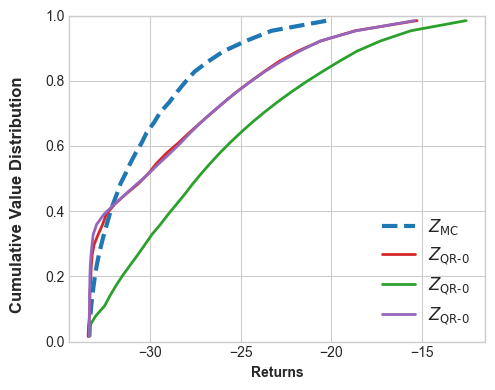

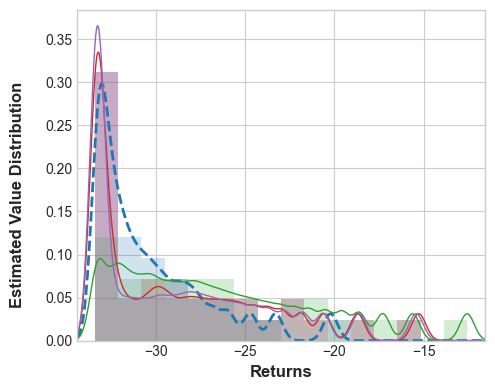

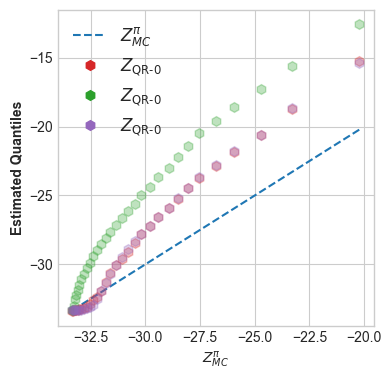

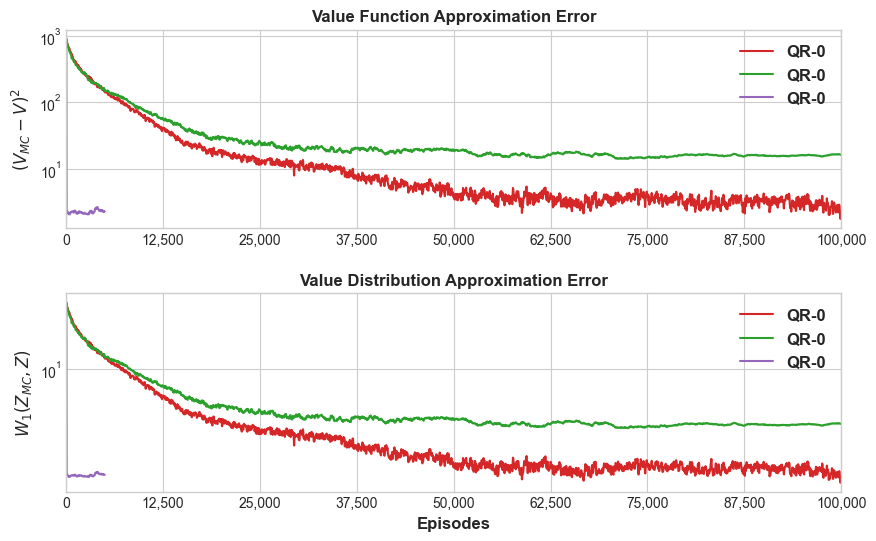

In [67]:
def get_q(table): return table[:,:,s_init].max(2)
def get_best(table): return get_q(table)[:,-1].mean(0)

plot_objs = [
    (get_best(table0), r"$Z_{\text{QR-0}}$"),
    (get_best(table1), r"$Z_{\text{QR-0}}$"),
    (get_best(table_init), r"$Z_{\text{QR-0}}$"),
]
plot_qs = [
    (get_q(table0), "QR-0"),
    (get_q(table1), "QR-0"),
    (get_q(table_init), "QR-0"),
    # (get_q(qtable), "Q-learning"),
]
LOW_BANDWIDTH = 0.004
bw = 0.4

plot_cdf(plot_objs, tau_returns, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{MC}}$")
plot_pdf(plot_objs, tau_returns, bandwidth=bw, show_hist=True, linewidth=1.0, N=params.N//2, hist_alpha=0.2, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to, alpha=0.3, markersize=7, lims=None)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.2,0.3], true_dist="{MC}")